# AIM

The aim of this project is to develop a machine learning-based Lead Scoring System that predicts the likelihood of a lead converting into a paying customer. By analyzing customer and lead-related data, the system assigns a lead score to each prospect, enabling the sales team to prioritize high-potential leads. This data-driven approach helps optimize sales efforts, improve resource utilization, and increase the lead conversion rate toward the company's target of 80%.

# IMPORTS

In [90]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
!pip install catboost
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score,accuracy_score,recall_score,precision_score,confusion_matrix,classification_report,roc_auc_score,roc_curve,RocCurveDisplay

**Reading and Understanding the data**

In [91]:
data=pd.read_csv('/content/Lead Scoring.csv')

In [92]:
df=pd.DataFrame(data)

In [93]:
df_copy=df.copy()

In [94]:
df.shape

(9240, 37)

In [95]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [96]:
cols_info=pd.read_excel('/content/Leads Data Dictionary.xlsx')

**Feature names and their descriptions.**

In [97]:
pd.set_option('display.max_colwidth', None)
cols_info = cols_info.drop(columns=['Unnamed: 0'])
cols_info=cols_info.rename(columns={'Unnamed: 1': 'Feature','Unnamed: 2': 'Description'})
cols_info = cols_info.iloc[2:].reset_index(drop=True)
cols_info.index = range(1, len(cols_info) + 1)
cols_info.index.name='SNo'
print(cols_info.to_markdown())

|   SNo | Feature                                          | Description                                                                                                                                                                       |
|------:|:-------------------------------------------------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
|     1 | Prospect ID                                      | A unique ID with which the customer is identified.                                                                                                                                |
|     2 | Lead Number                                      | A lead number assigned to each lead procured.                                                                                                                                     |
|     3 | Lead Origin               

In [98]:
df.duplicated().sum()

np.int64(0)

We can conclude that there are no duplicated rows.

In [99]:
df=df.drop({'Prospect ID','Lead Number'},axis=1)

Dropped Irrelevant columns

# Handling Missing Values

In [100]:
v=df.isnull().sum()
v[v>0]

,0
Lead Source,36
TotalVisits,137
Page Views Per Visit,137
Last Activity,103
Country,2461
Specialization,1438
How did you hear about X Education,2207
What is your current occupation,2690
What matters most to you in choosing a course,2709
Tags,3353


In [101]:
df_missing=pd.DataFrame(df.isnull().sum(),columns=['Missing'])
size,_=df.shape
df_missing['Percentage']=df_missing['Missing']/size*100
k=df_missing.sort_values(by='Percentage',ascending=False)
k[k['Percentage']>0]

,Missing,Percentage
Lead Quality,4767,51.590909
Asymmetrique Activity Index,4218,45.649351
Asymmetrique Activity Score,4218,45.649351
Asymmetrique Profile Score,4218,45.649351
Asymmetrique Profile Index,4218,45.649351
Tags,3353,36.287879
What matters most to you in choosing a course,2709,29.318182
Lead Profile,2709,29.318182
What is your current occupation,2690,29.112554
Country,2461,26.634199


Dropping cols with more than 40% of missing values.

In [102]:
drop_cols=df_missing[df_missing['Percentage']>40].index
df=df.drop(drop_cols,axis=1)
drop_cols=list(drop_cols)

Pipeline for dropped cols

In [103]:
df.shape

(9240, 30)

In [104]:
v=df.isnull().sum()
v[v>0]

,0
Lead Source,36
TotalVisits,137
Page Views Per Visit,137
Last Activity,103
Country,2461
Specialization,1438
How did you hear about X Education,2207
What is your current occupation,2690
What matters most to you in choosing a course,2709
Tags,3353


In [105]:
df['Lead Source'].value_counts(dropna=False)

,count
Lead Source,
Google,2868
Direct Traffic,2543
Olark Chat,1755
Organic Search,1154
Reference,534
Welingak Website,142
Referral Sites,125
Facebook,55
NaN,36


In [106]:
df['Lead Source']=df['Lead Source'].replace('google','Google')
df['Lead Source']=df['Lead Source'].fillna(df['Lead Source'].mode()[0])

Since there are very less missing values, filled them with mode.

In [107]:
df['TotalVisits'].dtype

dtype('float64')

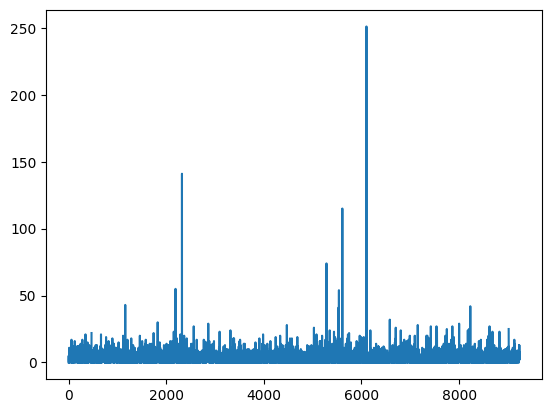

In [108]:
plt.plot(df['TotalVisits'])
plt.show()

Since there are large values at some positions mean will make the value skewed so let's go with mode.

In [109]:
df['TotalVisits']=df['TotalVisits'].fillna(df['TotalVisits'].median())

In [110]:
df['Page Views Per Visit'].describe()

,Page Views Per Visit
count,9103.000000
mean,2.362820
std,2.161418
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,55.000000


This also looks skewed so using median.

In [111]:
df['Page Views Per Visit']=df['Page Views Per Visit'].fillna(df['Page Views Per Visit'].median())

In [112]:
df['Last Activity'].value_counts(dropna=False)
df['Last Activity']=df['Last Activity'].fillna(df['Last Activity'].mode()[0])

In [113]:
df['Country'].value_counts(dropna=False)
df['Country']=df['Country'].fillna('Unknown')

Because there are nearly 2400 missing values if i fill with mode then it would lead to bias.

In [114]:
df['Specialization'].value_counts(dropna=False)
df['Specialization']=df['Specialization'].fillna('Not Mentioned')

In [115]:
df['How did you hear about X Education'].value_counts(dropna=False)

,count
How did you hear about X Education,
Select,5043
NaN,2207
Online Search,808
Word Of Mouth,348
Student of SomeSchool,310
Other,186
Multiple Sources,152
Advertisements,70
Social Media,67


Here Select doesn't make any sense according to the context. The select basically means the person hasn't chose any option so it is similar to NaN.

In [116]:
df['How did you hear about X Education']=df['How did you hear about X Education'].replace('Select','Not Mentioned')
df['How did you hear about X Education']=df['How did you hear about X Education'].fillna('Not Mentioned')

In [117]:
df['What is your current occupation'].value_counts(dropna=False)
df['What is your current occupation']=df['What is your current occupation'].fillna('Not Mentioned')

In [118]:
df['What matters most to you in choosing a course'].value_counts(dropna=False)

,count
What matters most to you in choosing a course,
Better Career Prospects,6528
NaN,2709
Flexibility & Convenience,2
Other,1


Ignoring the missing values, almost all records belong to a single category. Since the feature has very little variation, it is unlikely to provide useful information for the model and can be dropped.

In [119]:
df=df.drop('What matters most to you in choosing a course',axis=1)

In [120]:
df['Tags'].value_counts(dropna=False)
df=df.drop('Tags',axis=1)

Tags are the decisions made after interacting with lead. So this may directly affect the model(Data Leakage).

In [121]:
df['Lead Profile'].value_counts(dropna=False)

,count
Lead Profile,
Select,4146
NaN,2709
Potential Lead,1613
Other Leads,487
Student of SomeSchool,241
Lateral Student,24
Dual Specialization Student,20


In [122]:
df['Lead Profile']=df['Lead Profile'].replace('Select','Not Mentioned')
df['Lead Profile']=df['Lead Profile'].fillna('Not Mentioned')

In [123]:
df['City'].value_counts(dropna=False)

,count
City,
Mumbai,3222
Select,2249
NaN,1420
Thane & Outskirts,752
Other Cities,686
Other Cities of Maharashtra,457
Other Metro Cities,380
Tier II Cities,74


In [124]:
df['City']=df['City'].replace('Select','Not Mentioned')
df['City']=df['City'].fillna('Not Mentioned')

In [125]:
p=df.isnull().sum()
p[p>0]

,0


In [126]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(constant_cols)
df=df.drop(constant_cols,axis=1)

['Magazine', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque']


These features contain only one unique category across all observations. Since they do not provide any variation, they cannot help the model distinguish between converted and non-converted leads. Therefore, they were dropped.

In [127]:
df.shape

(9240, 23)

# Exploratory Data Analysis

In [128]:
df['Converted'].value_counts()

,count
Converted,
0,5679
1,3561


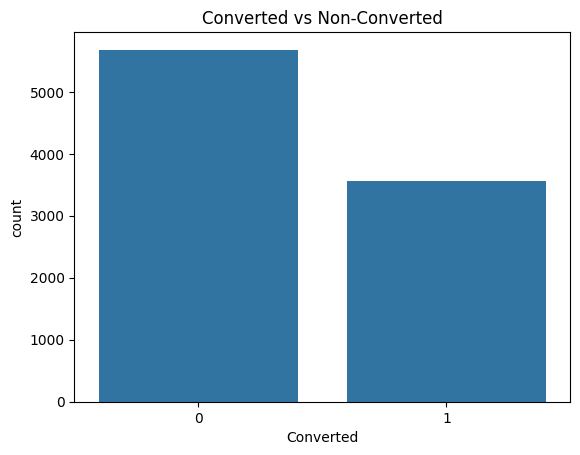

In [129]:
sns.countplot(x='Converted',data=df)
plt.title('Converted vs Non-Converted')
plt.show()

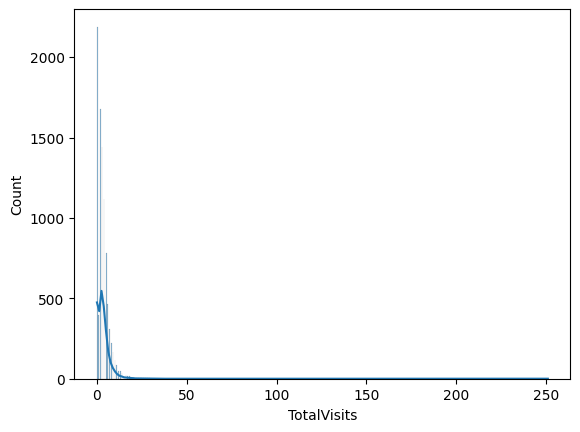

In [130]:
sns.histplot(df['TotalVisits'],kde=True)
plt.show()

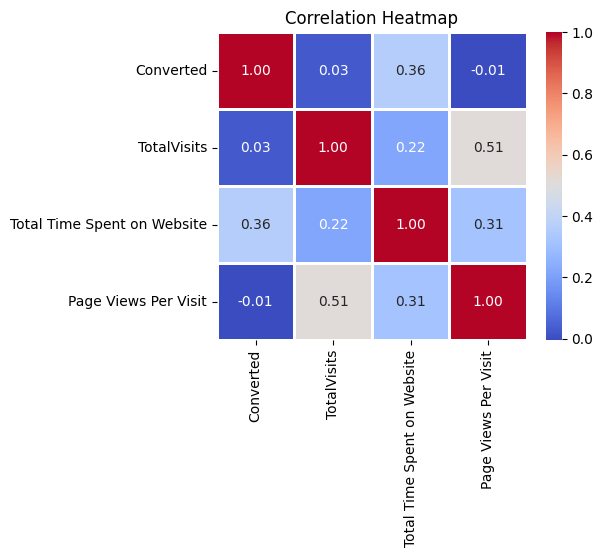

In [131]:
plt.figure(figsize=(5,4))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=2)
plt.title('Correlation Heatmap')
plt.show()

No two features are highly co-related.

In [132]:
num_cols=df.select_dtypes(include=['number']).columns.drop('Converted')
cat_cols=df.select_dtypes(exclude=['number']).columns

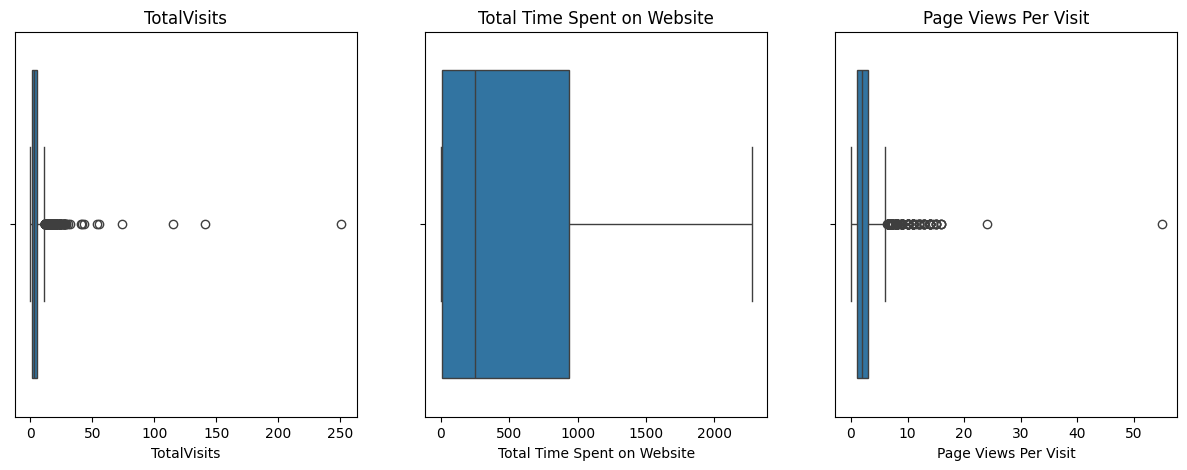

In [133]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.show()

# Outlier Detection and Handling

In [134]:
Q1=df['TotalVisits'].quantile(0.25)
Q3=df['TotalVisits'].quantile(0.75)
iqr=Q3-Q1;
lower=Q1-iqr*1.5
upper=Q3+iqr*1.5
df['TotalVisits']=df['TotalVisits'].clip(lower,upper)

In [135]:
Q1=df['Page Views Per Visit'].quantile(0.25)
Q3=df['Page Views Per Visit'].quantile(0.75)
iqr=Q3-Q1;
lower=Q1-iqr*1.5
upper=Q3+iqr*1.5
df['Page Views Per Visit']=df['Page Views Per Visit'].clip(lower,upper)

# PreProcessing

In [136]:
X=df.drop('Converted',axis=1)
y=df['Converted']

In [137]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [138]:
num_cols=X.select_dtypes(include=['number']).columns
cat_cols=X.select_dtypes(exclude=['number']).columns

In [139]:
num_pipeline=Pipeline([('Scaler',StandardScaler())])

In [140]:
cat_pipeline=Pipeline([('encoder',OneHotEncoder(handle_unknown='ignore'))])

In [141]:
preprocessor=ColumnTransformer([('num',num_pipeline,num_cols),('cat',cat_pipeline,cat_cols)])

# Logistic Regression

In [142]:
lr_pipeline=Pipeline([('preprocessor',preprocessor),('classifier',LogisticRegression(max_iter=1000,random_state=42))])

In [143]:
lr_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call',
       'Last Activity'...'Specialization',
       'How did you hear about X Education', 'What is your current occupation',
       'Search', 'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations', 'Lead Profile',
       'City', 'A free copy of Mastering The Interview',
       'Last Notable Activity'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [144]:
y_pred=lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

In [145]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8479437229437229
Precision: 0.8372434017595308
Recall   : 0.7705802968960864
F1 Score : 0.8025298664792692
ROC AUC  : 0.918160351194155


In [146]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1107
           1       0.84      0.77      0.80       741

    accuracy                           0.85      1848
   macro avg       0.85      0.84      0.84      1848
weighted avg       0.85      0.85      0.85      1848



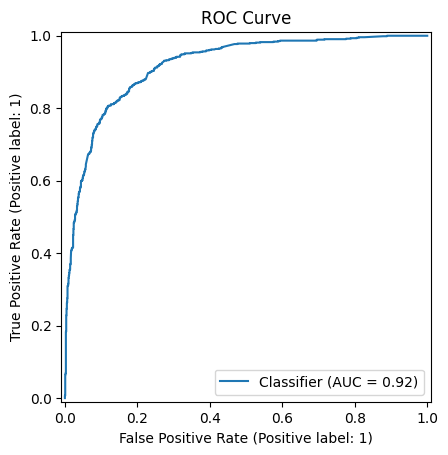

In [147]:
RocCurveDisplay.from_predictions(y_test,y_prob)
plt.title("ROC Curve")
plt.show()

Logistic Regression is giving better results of precision 0.83 and ROC-AUC of 0.91.

**Creating a function for training and evaluation of remaining models.**

In [148]:
def evaluate_model(model,X_train,X_test,y_train,y_test):
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:, 1]
  print("Accuracy :", accuracy_score(y_test, y_pred))
  print("Precision:", precision_score(y_test, y_pred))
  print("Recall   :", recall_score(y_test, y_pred))
  print("F1 Score :", f1_score(y_test, y_pred))
  print("ROC_AUC :", roc_auc_score(y_test, y_prob))
  print(classification_report(y_test, y_pred))
  RocCurveDisplay.from_predictions(y_test,y_prob)
  plt.title("ROC Curve")
  plt.show()
  return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    }

# Remaining Models

**Decision Tree Classifier, Random Forest Classifier, XGBClassifier, LGBMClassifier, CatBoostClassifier**

In [149]:
dt_pipeline=Pipeline([('preprocessor',preprocessor),('classifier',DecisionTreeClassifier(random_state=42))])
rf_pipeline=Pipeline([('preprocessor',preprocessor),('classifier',RandomForestClassifier(random_state=42))])
xgb_pipeline=Pipeline([('preprocessor',preprocessor),('classifier',XGBClassifier(random_state=42,eval_metric='logloss'))])
lgbm_pipeline=Pipeline([('preprocessor',preprocessor),('classifier',LGBMClassifier(random_state=42))])
cat_pipeline=Pipeline([('preprocessor',preprocessor),('classifier',CatBoostClassifier(verbose=0,random_state=42))])

In [150]:
results={}

Accuracy : 0.8479437229437229
Precision: 0.8372434017595308
Recall   : 0.7705802968960864
F1 Score : 0.8025298664792692
ROC_AUC : 0.918160351194155
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1107
           1       0.84      0.77      0.80       741

    accuracy                           0.85      1848
   macro avg       0.85      0.84      0.84      1848
weighted avg       0.85      0.85      0.85      1848



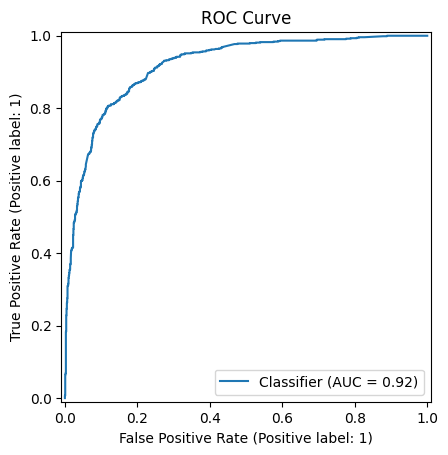

In [151]:
results["Logistic Regression"] = evaluate_model(lr_pipeline,X_train,X_test,y_train,y_test)

# Decision Tree

Accuracy : 0.7932900432900433
Precision: 0.7428958051420839
Recall   : 0.7408906882591093
F1 Score : 0.7418918918918919
ROC_AUC : 0.7844315465196937
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1107
           1       0.74      0.74      0.74       741

    accuracy                           0.79      1848
   macro avg       0.78      0.78      0.78      1848
weighted avg       0.79      0.79      0.79      1848



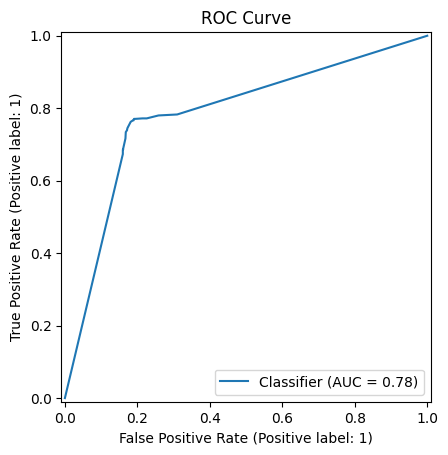

In [152]:
results["Decision Tree"] = evaluate_model(dt_pipeline,X_train,X_test,y_train,y_test)

In [153]:
train_pred = dt_pipeline.predict(X_train)
test_pred = dt_pipeline.predict(X_test)
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy :", accuracy_score(y_test, test_pred))

Training Accuracy: 0.97754329004329
Testing Accuracy : 0.7932900432900433


Here, Overfitting is happening in case of Decision Tree as there is a huge difference in training and testing accuracy.

# RandomForest

Accuracy : 0.8452380952380952
Precision: 0.8321167883211679
Recall   : 0.7692307692307693
F1 Score : 0.7994389901823282
ROC_AUC : 0.9128451383479197
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1107
           1       0.83      0.77      0.80       741

    accuracy                           0.85      1848
   macro avg       0.84      0.83      0.84      1848
weighted avg       0.84      0.85      0.84      1848



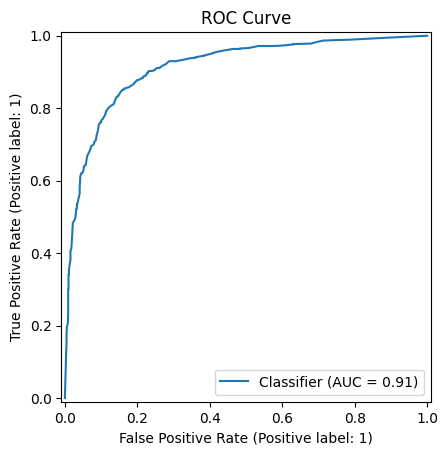

In [154]:
results["Random Forest"] = evaluate_model(rf_pipeline,X_train,X_test,y_train,y_test)

Without any hyperparamter tuning we can say the randomforest is performing slightly lesser than Logisitic Regression.

#XGBoost

Accuracy : 0.8425324675324676
Precision: 0.8223495702005731
Recall   : 0.7746288798920378
F1 Score : 0.797776233495483
ROC_AUC : 0.9155332219089174
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1107
           1       0.82      0.77      0.80       741

    accuracy                           0.84      1848
   macro avg       0.84      0.83      0.83      1848
weighted avg       0.84      0.84      0.84      1848



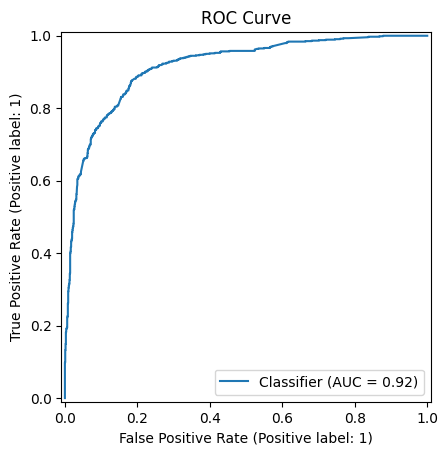

In [155]:
results["XGBoost"] = evaluate_model(xgb_pipeline,X_train,X_test,y_train,y_test)

It is performing goood without any any hyperparamters.

# LightGBM

[LightGBM] [Info] Number of positive: 2820, number of negative: 4572
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001966 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 7392, number of used features: 86
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.381494 -> initscore=-0.483214
[LightGBM] [Info] Start training from score -0.483214


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy : 0.8452380952380952
Precision: 0.8301886792452831
Recall   : 0.7719298245614035
F1 Score : 0.8
ROC_AUC : 0.9204900236136864
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1107
           1       0.83      0.77      0.80       741

    accuracy                           0.85      1848
   macro avg       0.84      0.83      0.84      1848
weighted avg       0.84      0.85      0.84      1848



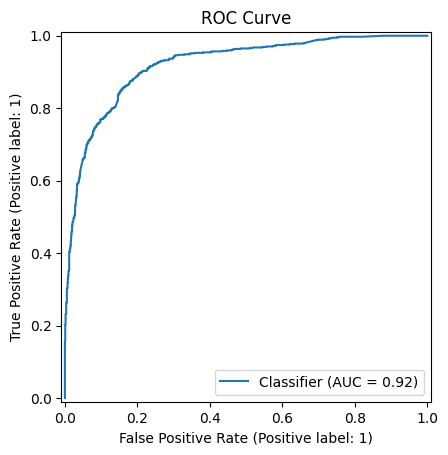

In [156]:
results["LightGBM"] = evaluate_model(lgbm_pipeline,X_train,X_test,y_train,y_test)

It is performing goood without any any hyperparamters.

# CatBoost

Accuracy : 0.8533549783549783
Precision: 0.844574780058651
Recall   : 0.7773279352226721
F1 Score : 0.8095572733661279
ROC_AUC : 0.9256089636919761
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1107
           1       0.84      0.78      0.81       741

    accuracy                           0.85      1848
   macro avg       0.85      0.84      0.85      1848
weighted avg       0.85      0.85      0.85      1848



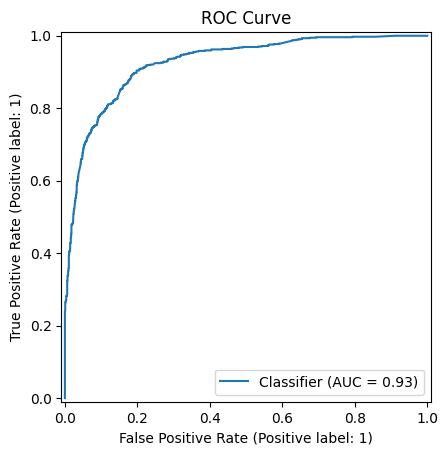

In [157]:
results["CatBoost"] = evaluate_model(cat_pipeline,X_train,X_test,y_train,y_test)

It is performing goood without any any hyperparamters.

In [158]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="ROC AUC", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
CatBoost,0.853355,0.844575,0.777328,0.809557,0.925609
LightGBM,0.845238,0.830189,0.771930,0.800000,0.920490
Logistic Regression,0.847944,0.837243,0.770580,0.802530,0.918160
XGBoost,0.842532,0.822350,0.774629,0.797776,0.915533
Random Forest,0.845238,0.832117,0.769231,0.799439,0.912845
Decision Tree,0.793290,0.742896,0.740891,0.741892,0.784432


In [159]:
param_dist = {
    'classifier__depth': [4, 6, 8, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__iterations': [200, 500, 1000],
    'classifier__l2_leaf_reg': [1, 3, 5, 7, 9]
}
random_cat = RandomizedSearchCV(
    estimator=cat_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
start = time.time()
random_cat.fit(X_train, y_train)
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = elapsed % 60
print(f"Time Taken: {hours}h {minutes}m {seconds:.2f}s")

Time Taken: 0h 4m 44.50s


It tool 4min 44sec for training.

In [160]:
best_cat = random_cat.best_estimator_

print("Best Parameters:")
print(random_cat.best_params_)

print("\nBest CV ROC-AUC:")
print(random_cat.best_score_)

Best Parameters:
{'classifier__learning_rate': 0.01, 'classifier__l2_leaf_reg': 3, 'classifier__iterations': 1000, 'classifier__depth': 6}

Best CV ROC-AUC:
0.917451543936124


In [161]:
y_pred = best_cat.predict(X_test)
y_prob = best_cat.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC_AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8593073593073594
Precision: 0.8573551263001485
Recall   : 0.7786774628879892
F1 Score : 0.8161244695898161
ROC_AUC  : 0.9269231378773528

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.91      0.89      1107
           1       0.86      0.78      0.82       741

    accuracy                           0.86      1848
   macro avg       0.86      0.85      0.85      1848
weighted avg       0.86      0.86      0.86      1848



This tuned model is performing better than all other trained models.with precision of 85%.

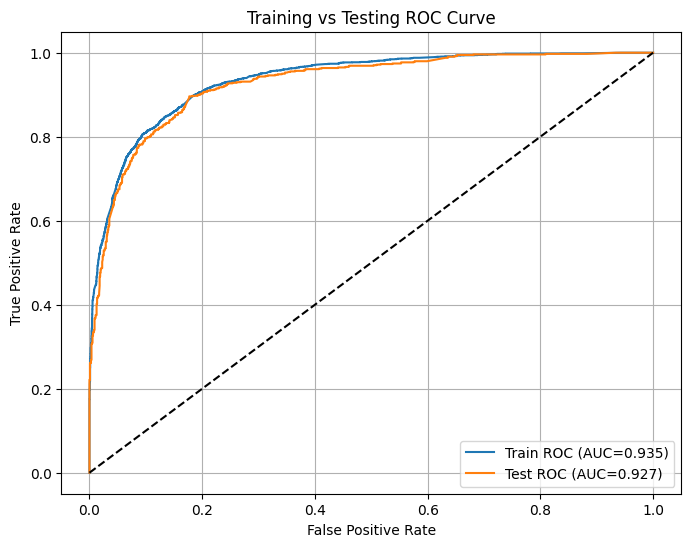

In [162]:
from sklearn.metrics import roc_curve, roc_auc_score

# Train probabilities
train_prob = best_cat.predict_proba(X_train)[:,1]

# Test probabilities
test_prob = best_cat.predict_proba(X_test)[:,1]

# ROC values
fpr_train, tpr_train, _ = roc_curve(y_train, train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, test_prob)

# AUC
auc_train = roc_auc_score(y_train, train_prob)
auc_test = roc_auc_score(y_test, test_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr_train, tpr_train,
         label=f"Train ROC (AUC={auc_train:.3f})")

plt.plot(fpr_test, tpr_test,
         label=f"Test ROC (AUC={auc_test:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Training vs Testing ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

Six machine learning algorithms were evaluated for the lead scoring problem. Among all the models, the tuned CatBoost classifier achieved the best overall performance with an Accuracy of 85.93%, Precision of 85.74%, Recall of 77.87%, F1-score of 81.61%, and ROC-AUC of 92.69%. The high precision indicates that the majority of leads predicted as potential customers were actual conversions, supporting efficient allocation of sales resources. Therefore, the tuned CatBoost model was selected as the final model for lead scoring.

In [163]:
lead_prob = best_cat.predict_proba(X)[:, 1]
lead_score = (lead_prob * 100).round(2)
final_leads = pd.DataFrame({
    'Lead Number': df_copy['Lead Number'].values,
    'Conversion Probability': lead_prob,
    'Lead Score': lead_score
})
final_leads = final_leads.sort_values(
    by='Conversion Probability',
    ascending=False
).reset_index(drop=True)

In [173]:
final_leads.to_csv('Lead_Scoring_Final.csv', index=False)

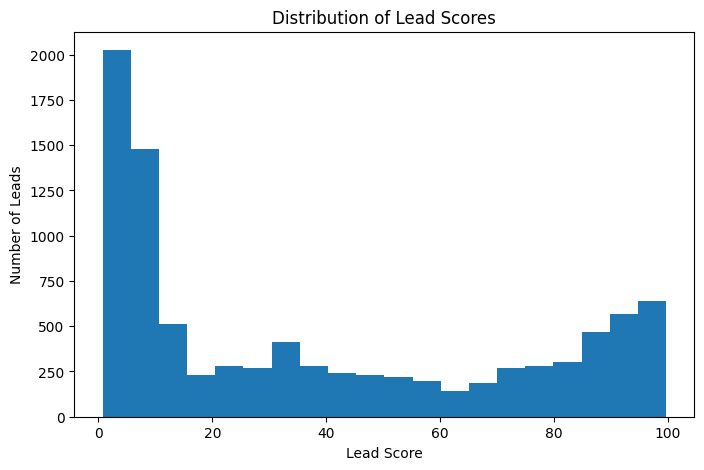

In [168]:
plt.figure(figsize=(8,5))
plt.hist(lead_score, bins=20)
plt.xlabel("Lead Score")
plt.ylabel("Number of Leads")
plt.title("Distribution of Lead Scores")
plt.show()

In [169]:
final_leads.head(10)

,Lead Number,Conversion Probability,Lead Score
0,612484,0.997347,99.73
1,612679,0.995919,99.59
2,644953,0.995809,99.58
3,595141,0.995766,99.58
4,584160,0.995578,99.56
5,581759,0.995566,99.56
6,613438,0.995352,99.54
7,607283,0.995077,99.51
8,592625,0.995017,99.50
9,612639,0.995004,99.50


From the data given without considering the Converted feature, predicted the lead score and genereated a csv file of the information of the leads so that sales team can focus on the leads based on lead score.

In [170]:
import joblib
joblib.dump(best_cat, "best_cat.pkl")

['best_cat.pkl']